# AC One — News-Adjusted Fuel Consumption Forecasting

This use case starts **after** an external XGBoost model has produced monthly station forecasts. A cutoff-aware news agent may adjust each point forecast. The CSV stores two paired scales:

- `forecast_minmax` scored against `actual_minmax`
- `forecast_indexed` scored against `actual_indexed`

There is no unsuffixed `forecast` or `actual` column. Both scales are run through the same baseline and agent pipeline so you can see which input produces better MAE/MAPE.

- Stations: `STATION_A`, `STATION_B` (anonymized)
- Horizons: 1, 2, and 3 months
- Primary metrics: MAE and MAPE (lower is better). MAE is **not** comparable across scales; MAPE is.
- Langfuse traces go to project `air-canada-1` via `LANGFUSE_*` keys

`horizon_date` is the forecast origin (issue month). The target month is `horizon_date` plus `month_horizon`.

In [10]:
# Pick up edits to ac_one/*.py without restarting the kernel.
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
from dotenv import load_dotenv


ROOT = Path.cwd().resolve()
while not (ROOT / "implementations" / "ac_one").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
load_dotenv(ROOT / ".env", override=False)

# Live agent calls use the Vector proxy and cutoff verifier. Keep False for a free Run All.
RUN_AGENT = True
# Set True to discard cached prediction artifacts under data/predictions/.
FORCE_REFRESH = False
RUN_TRACE_EVAL = True
RUN_RATIONALE_JUDGE = False  # extra LLM calls; keep False for a free Run All
AGENT_MODEL = "gemini-3.1-flash-lite-preview"
# AGENT_MODEL = "gemini-3.5-flash"  # advanced alternative
FORECAST_SCALES = ("minmax", "indexed")

from ac_one.analysis import (
    improvement_display_formats,
    metric_display_formats,
    metric_summary,
    paired_improvement,
    predictions_to_frame,
)
from ac_one.analyst_agent import build_fuel_adjustment_config, build_fuel_adjustment_predictor
from ac_one.data import build_ac_one_service, load_forecast_data
from ac_one.predictors import ExternalForecastPredictor
from ac_one.specs import build_backtest_specs, load_experiment_spec
from ac_one.trace_eval import (
    LANGFUSE_PROJECT_NAME,
    connect_langfuse,
    evaluate_trace_forecasts,
    trace_ids_from_results,
)
from aieng.forecasting.evaluation import cached_backtest, load_backtest_result


STORE_DIR = ROOT / "data" / "predictions"
langfuse = connect_langfuse()
print("RUN_AGENT =", RUN_AGENT, "| model =", AGENT_MODEL)
print("FORECAST_SCALES =", FORECAST_SCALES)
print(langfuse.message)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
RUN_AGENT = True | model = gemini-3.1-flash-lite-preview
FORECAST_SCALES = ('minmax', 'indexed')
Authenticated to Langfuse project 'air-canada-1' at https://us.cloud.langfuse.com.


## 1. Load and validate the anonymized export

The loader validates required columns, unique forecast keys, consistent actuals for each target month, and positive horizons. Each scale is a first-class experiment input and is never mixed with the other scale's actuals.

In [11]:
data = load_forecast_data()
service = build_ac_one_service(data)
experiment = load_experiment_spec()

print(f"Rows: {len(data)} | stations: {sorted(data.station.unique())}")
display(
    data[
        [
            "station",
            "region",
            "forecast_origin",
            "horizon_date",
            "month_horizon",
            "target_month",
            "forecast_minmax",
            "actual_minmax",
            "forecast_indexed",
            "actual_indexed",
            "model_version",
        ]
    ].head(9)
)

Rows: 30 | stations: ['STATION_A', 'STATION_B']


,station,region,forecast_origin,horizon_date,month_horizon,target_month,forecast_minmax,actual_minmax,forecast_indexed,actual_indexed,model_version
0,STATION_A,west,2026-01-01,2026-01-01,1,2026-02-01,0.2625,0.2277,100.00,95.21,bundle_015
1,STATION_A,west,2026-01-01,2026-01-01,2,2026-03-01,0.1763,0.1699,88.12,87.24,bundle_015
2,STATION_A,west,2026-01-01,2026-01-01,3,2026-04-01,0.2616,0.2681,99.88,100.77,bundle_015
3,STATION_A,west,2026-02-01,2026-02-01,1,2026-03-01,0.1758,0.1699,88.05,87.24,bundle_016
4,STATION_A,west,2026-02-01,2026-02-01,2,2026-04-01,0.2656,0.2681,100.43,100.77,bundle_016
5,STATION_A,west,2026-02-01,2026-02-01,3,2026-05-01,0.1727,0.1835,87.63,89.12,bundle_016
6,STATION_A,west,2026-03-01,2026-03-01,1,2026-04-01,0.2623,0.2681,99.98,100.77,bundle_017
7,STATION_A,west,2026-03-01,2026-03-01,2,2026-05-01,0.1727,0.1835,87.63,89.12,bundle_017
8,STATION_A,west,2026-03-01,2026-03-01,3,2026-06-01,0.2413,0.2273,97.09,95.16,bundle_017


## 2. Run the external-model baseline on both scales

Each station × horizon is a standard `BacktestSpec` with a ragged origin list (six / five / four origins at 1- / 2- / 3-month leads). The adapter returns the scale-specific XGBoost value. Cache keys include the scale so minmax and indexed artifacts cannot overwrite each other.

In [12]:
baseline_by_scale = {}
specs_by_scale = {}
for scale in FORECAST_SCALES:
    specs = build_backtest_specs(experiment, data, forecast_scale=scale)
    specs_by_scale[scale] = specs
    baseline = ExternalForecastPredictor(data, forecast_scale=scale)
    case_results = {}
    for case_name, spec in specs.items():
        case_results[case_name] = cached_backtest(
            predictor=baseline,
            spec=spec,
            spec_id=f"{experiment.spec_id}_{scale}_{case_name}",
            data_service=service,
            store_dir=STORE_DIR,
            force_refresh=FORCE_REFRESH,
        )
    baseline_by_scale[scale] = case_results
    n = sum(len(result.predictions) for result in case_results.values())
    print(f"{scale}: scored {n} baseline forecasts.")

minmax: scored 30 baseline forecasts.
indexed: scored 30 baseline forecasts.


## 3. Run or load the news-adjusted agent on both scales

The agent sees only the issue date, target month, anonymized station/region, horizon, forecast scale, and that scale's external model forecast. Search is fenced to the issue date. Adjustments are capped at ±20%.

A full run makes 30 analyst calls per scale plus search/verifier calls. Set `RUN_AGENT = True` deliberately. Completed cases are cached independently. Traces are tagged for Langfuse project `air-canada-1`.

In [13]:
agent_by_scale = {}
if RUN_AGENT and not langfuse.ok:
    print("Agent tracing will not reach Langfuse until credentials for", LANGFUSE_PROJECT_NAME, "are valid.")

for scale in FORECAST_SCALES:
    specs = specs_by_scale[scale]
    agent_predictor_id = f"agent_predictor_ac_one_fuel_news_adjuster_{scale}_{AGENT_MODEL}_continuous"
    case_results = {}
    if RUN_AGENT:
        config = build_fuel_adjustment_config(model=AGENT_MODEL, forecast_scale=scale)
        agent = build_fuel_adjustment_predictor(
            data,
            forecast_scale=scale,
            config=config,
            enable_langfuse_tracing=langfuse.ok,
        )
        agent_predictor_id = agent.predictor_id
        for case_name, spec in specs.items():
            case_results[case_name] = cached_backtest(
                predictor=agent,
                spec=spec,
                spec_id=f"{experiment.spec_id}_{scale}_{case_name}",
                data_service=service,
                store_dir=STORE_DIR,
                force_refresh=FORCE_REFRESH,
            )
    else:
        for case_name in specs:
            cached = load_backtest_result(
                f"{experiment.spec_id}_{scale}_{case_name}",
                agent_predictor_id,
                store_dir=STORE_DIR,
            )
            if cached is not None:
                case_results[case_name] = cached
    agent_by_scale[scale] = case_results
    print(f"{scale}: loaded {len(case_results)}/{len(specs)} agent cases ({agent_predictor_id}).")

if not any(agent_by_scale.values()):
    print("No cached agent results yet. Set RUN_AGENT = True to generate the comparison.")

minmax: loaded 6/6 agent cases (agent_predictor_ac_one_fuel_news_adjuster_minmax_gemini-3.1-flash-lite-preview_continuous).
indexed: loaded 6/6 agent cases (agent_predictor_ac_one_fuel_news_adjuster_indexed_gemini-3.1-flash-lite-preview_continuous).


## 4. Compare MAE and MAPE

Each scale is scored against its matching actual. MAE units differ (`minmax` is roughly 0–1; `indexed` is larger), so do not rank scales by MAE. Rank scales by MAPE, then look at paired agent-vs-baseline improvement within each scale.

A mean improvement of exactly 0 means the agent left the baseline unchanged for those cases — that is a real result, not a missing actual.

In [14]:
scored_frames = []
for scale in FORECAST_SCALES:
    results = {"External XGBoost": baseline_by_scale[scale]}
    agent_results = agent_by_scale[scale]
    if len(agent_results) == len(specs_by_scale[scale]):
        results["News-adjusted agent"] = agent_results
    scored_frames.append(predictions_to_frame(results, data, forecast_scale=scale))

scored = pd.concat(scored_frames, ignore_index=True) if scored_frames else pd.DataFrame()
overall = metric_summary(scored)
print("Overall (MAE is scale-specific; compare MAPE across scales)")
display(overall.style.format(metric_display_formats()))
display(metric_summary(scored, by=["horizon"]).style.format(metric_display_formats()))
display(metric_summary(scored, by=["station"]).style.format(metric_display_formats()))

if set(overall["predictor"]) >= {"External XGBoost"}:
    baseline_mape = overall[overall["predictor"] == "External XGBoost"].nsmallest(1, "mape_pct")
    print(
        "Lowest-MAPE external scale:",
        baseline_mape["forecast_scale"].iloc[0],
        f"MAPE={baseline_mape['mape_pct'].iloc[0]:.2f}%",
    )

Overall (MAE is scale-specific; compare MAPE across scales)


,forecast_scale,predictor,mae,mape_pct,n_forecasts
0,indexed,External XGBoost,5.567,6.21,30
1,indexed,News-adjusted agent,6.291,6.97,30
2,minmax,External XGBoost,0.056,20.24,30
3,minmax,News-adjusted agent,0.063,21.43,30


,forecast_scale,horizon,predictor,mae,mape_pct,n_forecasts
0,indexed,1,External XGBoost,4.978,5.50,12
1,indexed,1,News-adjusted agent,6.248,6.79,12
2,indexed,2,External XGBoost,5.162,5.80,10
3,indexed,2,News-adjusted agent,5.255,5.86,10
4,indexed,3,External XGBoost,6.956,7.79,8
5,indexed,3,News-adjusted agent,7.650,8.61,8
6,minmax,1,External XGBoost,0.050,17.34,12
7,minmax,1,News-adjusted agent,0.058,18.44,12
8,minmax,2,External XGBoost,0.052,19.31,10
9,minmax,2,News-adjusted agent,0.053,19.05,10


,forecast_scale,station,predictor,mae,mape_pct,n_forecasts
0,indexed,STATION_A,External XGBoost,4.762,5.86,15
1,indexed,STATION_A,News-adjusted agent,5.020,6.16,15
2,indexed,STATION_B,External XGBoost,6.372,6.55,15
3,indexed,STATION_B,News-adjusted agent,7.562,7.77,15
4,minmax,STATION_A,External XGBoost,0.035,29.76,15
5,minmax,STATION_A,News-adjusted agent,0.036,30.64,15
6,minmax,STATION_B,External XGBoost,0.078,10.72,15
7,minmax,STATION_B,News-adjusted agent,0.089,12.23,15


Lowest-MAPE external scale: indexed MAPE=6.21%


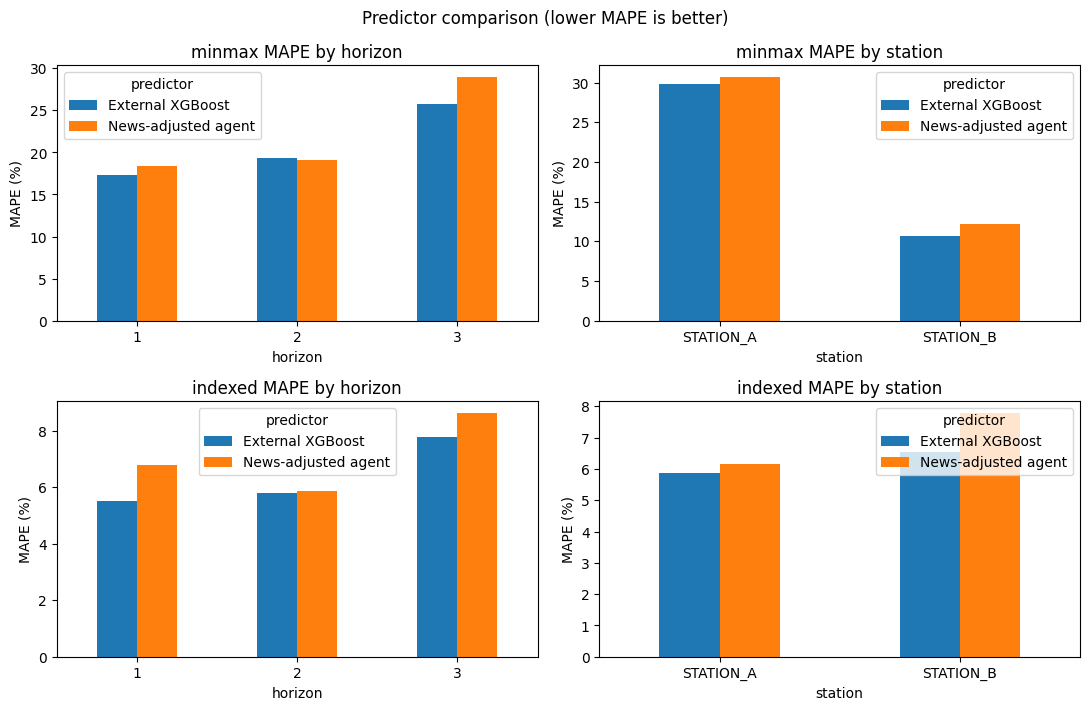

In [15]:
import matplotlib.pyplot as plt

by_horizon = metric_summary(scored, by=["horizon"])
by_station = metric_summary(scored, by=["station"])
scales = [scale for scale in FORECAST_SCALES if scale in set(scored["forecast_scale"])]
fig, axes = plt.subplots(len(scales), 2, figsize=(11, 3.6 * max(len(scales), 1)), squeeze=False)
for row, scale in enumerate(scales):
    horizon_panel = by_horizon[by_horizon["forecast_scale"] == scale]
    station_panel = by_station[by_station["forecast_scale"] == scale]
    horizon_panel.pivot(index="horizon", columns="predictor", values="mape_pct").plot(
        kind="bar", ax=axes[row, 0], rot=0
    )
    axes[row, 0].set_title(f"{scale} MAPE by horizon")
    axes[row, 0].set_ylabel("MAPE (%)")
    station_panel.pivot(index="station", columns="predictor", values="mape_pct").plot(
        kind="bar", ax=axes[row, 1], rot=0
    )
    axes[row, 1].set_title(f"{scale} MAPE by station")
    axes[row, 1].set_ylabel("MAPE (%)")
fig.suptitle("Predictor comparison (lower MAPE is better)")
fig.tight_layout()
plt.show()

In [16]:
if "News-adjusted agent" in set(scored.get("predictor", [])):
    display(paired_improvement(scored).style.format(improvement_display_formats()))
    display(paired_improvement(scored, by=["horizon"]).style.format(improvement_display_formats()))
else:
    print("Agent comparison becomes available after all six cached cases exist for a scale.")

,forecast_scale,mean_mae_improvement,mean_mape_improvement_pct_points,n_pairs,win_rate_pct
0,indexed,-0.724,-0.76,30,6.7
1,minmax,-0.006,-1.19,30,13.3


,forecast_scale,horizon,mean_mae_improvement,mean_mape_improvement_pct_points,n_pairs,win_rate_pct
0,indexed,1,-1.270,-1.29,12,0.0
1,indexed,2,-0.093,-0.06,10,10.0
2,indexed,3,-0.694,-0.82,8,12.5
3,minmax,1,-0.007,-1.10,12,16.7
4,minmax,2,-0.001,0.25,10,10.0
5,minmax,3,-0.011,-3.14,8,12.5


## 5. Audit adjustments, rationales, and Langfuse traces

Inspect adjustment size, rationale, evidence, sources, and the Langfuse URL in project `air-canada-1`. Large or frequently one-directional changes are warning signs, especially with only 30 forecast cases per scale.

In [17]:
agent_audit = scored[scored["predictor"] == "News-adjusted agent"][
    [
        "forecast_scale",
        "station",
        "origin",
        "target_month",
        "horizon",
        "forecast",
        "actual",
        "adjustment_pct",
        "absolute_error",
        "rationale",
        "evidence_summary",
        "source_urls",
        "langfuse_trace_url",
    ]
]
display(agent_audit) if not agent_audit.empty else print("No agent forecasts loaded.")

,forecast_scale,station,origin,target_month,horizon,forecast,actual,adjustment_pct,absolute_error,rationale,evidence_summary,source_urls,langfuse_trace_url
30,minmax,STATION_A,2026-01-01,2026-02-01,1,0.262500,0.2277,0.000000,0.034800,While meteorological forecasts as of January 1...,"As of the January 1, 2026, cutoff, meteorologi...",[https://www.weather.gov/news/260101-winter-ou...,https://us.cloud.langfuse.com/project/cmqqnzkf...
31,minmax,STATION_A,2026-02-01,2026-03-01,1,0.175800,0.1699,0.000000,0.005900,"No specific, actionable evidence of operationa...",A review of industry conditions as of February...,[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
32,minmax,STATION_A,2026-01-01,2026-03-01,2,0.176300,0.1699,0.000000,0.006400,"The baseline forecast, generated by an XGBoost...","As of the January 1, 2026, cutoff, the aviatio...",[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
33,minmax,STATION_A,2026-03-01,2026-04-01,1,0.262300,0.2681,0.000000,0.005800,"The baseline forecast, generated by the XGBoos...","As of March 1, 2026, the aviation industry fac...",[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
34,minmax,STATION_A,2026-02-01,2026-04-01,2,0.265600,0.2681,0.000000,0.002500,"The baseline forecast, generated by an XGBoost...","As of February 1, 2026, the aviation industry ...",[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
35,minmax,STATION_A,2026-01-01,2026-04-01,3,0.261600,0.2681,0.000000,0.006500,"The available information as of January 1, 202...",Industry outlooks as of early 2026 highlight s...,[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
36,minmax,STATION_A,2026-04-01,2026-05-01,1,0.175000,0.1835,4.979004,0.008500,The baseline forecast is adjusted upward by ap...,"As of April 1, 2026, the aviation industry is ...",[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
37,minmax,STATION_A,2026-03-01,2026-05-01,2,0.172700,0.1835,0.000000,0.010800,While a significant geopolitical event (Strait...,A geopolitical shock involving the closure of ...,[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
38,minmax,STATION_A,2026-02-01,2026-05-01,3,0.172700,0.1835,0.000000,0.010800,"The baseline forecast, generated by the organi...",Industry outlooks as of February 2026 indicate...,[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...
39,minmax,STATION_A,2026-05-01,2026-06-01,1,0.234000,0.2273,4.932735,0.006700,The global energy market shock and record-high...,"As of May 1, 2026, the aviation industry is fa...",[https://vertexaisearch.cloud.google.com/groun...,https://us.cloud.langfuse.com/project/cmqqnzkf...


## 6. Push trace scores to Langfuse

`RUN_TRACE_EVAL = True` fetches each agent trace, joins the matching `actual_*` column, and writes deterministic scores (`absolute_error`, `ape_pct`, improvements, `adjustment_pct`) back to `air-canada-1`.

`RUN_RATIONALE_JUDGE = True` adds extra LLM-as-judge calls for rationale quality. Leave it false for a free Run All.

In [18]:
if RUN_TRACE_EVAL:
    if not langfuse.ok:
        print(langfuse.message)
    else:
        trace_ids = []
        for scale in FORECAST_SCALES:
            trace_ids.extend(trace_ids_from_results(agent_by_scale[scale]))
        if not trace_ids:
            print("No Langfuse trace ids on cached agent predictions yet. Re-run with RUN_AGENT = True.")
        else:
            trace_scores = evaluate_trace_forecasts(
                trace_ids,
                data,
                push_to_langfuse=True,
                run_judge=RUN_RATIONALE_JUDGE,
                client=langfuse.client,
            )
            print(f"Scored {len(trace_scores)} traces in project {LANGFUSE_PROJECT_NAME}.")
            display(trace_scores)
else:
    print("Trace evaluation skipped. Set RUN_TRACE_EVAL = True after agent traces exist.")

Scored 60 traces in project air-canada-1.


,forecast_scale,station,target_month,horizon,forecast,actual,absolute_error,ape_pct,baseline_forecast,mae_improvement,mape_improvement_pct_points,adjustment_pct,rationale_quality,adjustment_justified,cutoff_safe,judge_justification,langfuse_trace_id,langfuse_trace_url,langfuse_scored
0,minmax,STATION_A,2026-02-01,1,0.262500,0.2277,0.034800,15.283267,0.2625,0.000000,0.000000,0.000000,None,None,None,None,f8e044a66976b57daea8cd2eb850bef7,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
1,minmax,STATION_A,2026-03-01,1,0.175800,0.1699,0.005900,3.472631,0.1758,0.000000,0.000000,0.000000,None,None,None,None,221393e7881bd7cb2c47c531efcffc63,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
2,minmax,STATION_A,2026-04-01,1,0.262300,0.2681,0.005800,2.163372,0.2623,0.000000,0.000000,0.000000,None,None,None,None,b3608ec02db69cc5b08ee1a99cd352c3,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
3,minmax,STATION_A,2026-05-01,1,0.175000,0.1835,0.008500,4.632153,0.1667,0.008300,4.523161,4.979004,None,None,None,None,eb60f16d7dd21cbd0fcb70c6b23c14a8,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
4,minmax,STATION_A,2026-06-01,1,0.234000,0.2273,0.006700,2.947646,0.2230,-0.002400,-1.055873,4.932735,None,None,None,None,0201a0a49c2aab6a3afed2332b9881e1,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
5,minmax,STATION_A,2026-07-01,1,0.223700,0.1000,0.123700,123.700000,0.2193,-0.004400,-4.400000,2.006384,None,None,None,None,24f3f5ed2ffd9402d75bee01fff8309e,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
6,minmax,STATION_A,2026-03-01,2,0.176300,0.1699,0.006400,3.766922,0.1763,0.000000,0.000000,0.000000,None,None,None,None,8c89ae08aa08b3cc266b0564fd3d4110,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
7,minmax,STATION_A,2026-04-01,2,0.265600,0.2681,0.002500,0.932488,0.2656,0.000000,0.000000,0.000000,None,None,None,None,09daac7219dfaa7512a2b872bf447cfb,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
8,minmax,STATION_A,2026-05-01,2,0.172700,0.1835,0.010800,5.885559,0.1727,0.000000,0.000000,0.000000,None,None,None,None,e6b211a3c1abfe0e7306517134d18a07,https://us.cloud.langfuse.com/project/cmqqnzkf...,True
9,minmax,STATION_A,2026-06-01,2,0.265600,0.2273,0.038300,16.849978,0.2459,-0.019700,-8.666960,8.011387,None,None,None,None,dc5eae15f6cda36727498757e977be80,https://us.cloud.langfuse.com/project/cmqqnzkf...,True


## Interpretation limits

- This anonymized sample has only 30 station/origin/horizon rows per scale, so differences are descriptive rather than statistically decisive.
- The station labels do not reveal airports or route networks; the agent must not pretend otherwise.
- News adjustment should be judged against the external model on the **same** scale, not against a naive time-series baseline.
- Re-running the same historical window while tuning prompts turns it into development data. Reserve newer months for a protected evaluation before operational use.